In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy.stats as stat

import cmocean.cm as cm

from pathlib import Path

from matplotlib.patches import Rectangle


In [2]:
versions = ["202111", "202606"]

period = "2015–2020"

In [3]:
# Variables
variables = {
    "Salinity":{
        "obs":"Salinity",
        "mod":"mod_vosaline",
        "unit":"g kg$^{-1}$",
        "limits":(20,36),
    },
    "Temperature":{
        "obs":"Temperature",
        "mod":"mod_votemper",
        "unit":"$^{\\circ}$C",
        "limits":(2,22),
    },
    "DO":{
        "obs":"Oxygen_Dissolved",
        "mod":"mod_dissolved_oxygen",
        "unit":"mmol O$_2$ m$^{-3}$",
        "limits":(0,350),
    },
    "NO3":{
        "obs":"NO3",
        "mod":"mod_nitrate",
        "unit":"mmol N m$^{-3}$",
        "limits":(0,40),
    }
}

In [4]:
mesh_file = "/ocean/atall/MOAD/grid/mesh_mask202605.nc"
with nc.Dataset(mesh_file) as mesh:
    navlon = mesh["nav_lon"][:]
    navlat = mesh["nav_lat"][:]
    tmask = mesh["tmask"][:]
bathy = nc.Dataset('/ocean/atall/MOAD/grid/bathymetry_202605.nc','r')

In [5]:
regions = {
    "JdF":{
        "i":(25,125),
        "j":(250,425),
    },
    "SoG":{
        "i":(100,300),
        "j":(400,600),
    },
    "PS":{
        "i":(50,350),
        "j":(0,200),
    }
}

In [6]:
depth_bins = {
    "Surface":(0,10),
    "Shallow":(10,50),
    "Subsurface":(50,200),
    "Deep":(200,450),
}

In [7]:
# data
pnw202111_15 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111daily/ObsModel_202111_pnw_20150101_20151231.csv')
pnw202606_15 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202606daily/ObsModel_202606_pnw_20150101_20151231.csv')
pnw202111_16 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111daily/ObsModel_202111_pnw_20160101_20161231.csv')
pnw202606_16 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202606daily/ObsModel_202606_pnw_20160101_20161231.csv')
pnw202111_17 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111daily/ObsModel_202111_pnw_20170101_20171231.csv')
pnw202606_17 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202606daily/ObsModel_202606_pnw_20170101_20171231.csv')
pnw202111_18 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111daily/ObsModel_202111_pnw_20180101_20181231.csv')
pnw202606_18 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202606daily/ObsModel_202606_pnw_20180101_20181231.csv')
pnw202111_19 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111daily/ObsModel_202111_pnw_20190101_20191231.csv')
pnw202606_19 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202606daily/ObsModel_202606_pnw_20190101_20191231.csv')
pnw202111_20 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202111daily/ObsModel_202111_pnw_20200101_20201231.csv')
pnw202606_20 = pd.read_csv('/ocean/atall/MOAD/ObsModel/202606daily/ObsModel_202606_pnw_20200101_20201231.csv')

pnw202111 = pd.concat([pnw202111_15, pnw202111_16, pnw202111_17, pnw202111_18, pnw202111_19, pnw202111_20
                       ], ignore_index=True)
pnw202606 = pd.concat([pnw202606_15, pnw202606_16, pnw202606_17, pnw202606_18, pnw202606_19, pnw202606_20
                       ], ignore_index=True)

In [8]:
model_data = {"202111": pnw202111,"202606": pnw202606}
regional_data = {}
for version, df in model_data.items():
    regional_data[version] = {}
    for region, bounds in regions.items():
        i0, i1 = bounds["i"]
        j0, j1 = bounds["j"]
        regional_data[version][region] = df[df["i"].between(i0, i1) & df["j"].between(j0, j1)].copy()

In [9]:
# Statistics
def compute_stats(obs, mod):

    obs = np.asarray(obs)
    mod = np.asarray(mod)

    mask = np.isfinite(obs) & np.isfinite(mod)

    obs = obs[mask]
    mod = mod[mask]

    if len(obs) == 0:
        return {"N":0,"RMSE":np.nan,"Bias":np.nan,"WSS":np.nan}
    mse = np.mean((mod-obs)**2)
    rmse = np.sqrt(mse)
    bias = np.mean(mod-obs)
    wss = 1 - mse / np.mean((np.abs(mod-obs.mean()) + np.abs(obs-obs.mean()))**2)

    return {"N":len(obs),"RMSE":rmse,"Bias":bias,"WSS":wss}

In [10]:
# Compute statistics by depth
def compute_depth_stats(df,obs_var,mod_var,depth_var="Z"):
    rows = []
    for depth_name, (zmin, zmax) in depth_bins.items():
        subset = df[(df[depth_var] >= zmin) & (df[depth_var] < zmax)]
        stats = compute_stats(subset[obs_var],subset[mod_var])
        stats["Depth"] = depth_name
        rows.append(stats)
    return pd.DataFrame(rows)

In [11]:
# Compute statistics for all regions
depth_stats = []

for version in versions:

    for region in regions:

        df = regional_data[version][region]

        for variable in variables:

            obs = variables[variable]["obs"]
            mod = variables[variable]["mod"]

            stats = compute_depth_stats(df,obs,mod)

            stats["Version"] = version
            stats["Region"] = region
            stats["Variable"] = variable

            depth_stats.append(stats)

depth_stats = pd.concat(depth_stats,ignore_index=True)

In [12]:
# Overall statistics
overall_stats = []

for version in versions:

    df = model_data[version]

    for variable in variables:

        obs = variables[variable]["obs"]
        mod = variables[variable]["mod"]

        stats = compute_stats(df[obs],df[mod])

        stats["Variable"] = variable
        stats["Version"] = version

        overall_stats.append(stats)

overall_stats = pd.DataFrame(overall_stats)

In [13]:
table = depth_stats[depth_stats["Variable"] == "DO"]
table

,N,RMSE,Bias,WSS,Depth,Version,Region,Variable
8,144,29.313901,-0.365240,0.888178,Surface,202111,JdF,DO
9,260,18.662797,1.959797,0.953490,Shallow,202111,JdF,DO
10,401,19.121346,-2.776214,0.967338,Subsurface,202111,JdF,DO
11,27,20.732219,-12.137795,0.874921,Deep,202111,JdF,DO
24,653,34.080613,-6.531572,0.759969,Surface,202111,SoG,DO
25,902,25.589155,0.379385,0.927124,Shallow,202111,SoG,DO
26,1043,12.071050,0.584572,0.956429,Subsurface,202111,SoG,DO
27,447,16.796004,12.238330,0.747737,Deep,202111,SoG,DO
40,10655,52.726174,-20.223711,0.777203,Surface,202111,PS,DO
41,35174,30.665425,-15.081084,0.886984,Shallow,202111,PS,DO


In [14]:
overall_stats[overall_stats["Version"] == "202111"]

,N,RMSE,Bias,WSS,Variable,Version
0,160915,0.705745,-0.085827,0.947619,Salinity,202111
1,153793,0.613998,-0.118876,0.970264,Temperature,202111
2,145224,27.895645,-11.340228,0.920381,DO,202111
3,15208,4.425761,-1.436423,0.918258,NO3,202111


In [15]:

overall_stats[overall_stats["Version"] == "202606"]

,N,RMSE,Bias,WSS,Variable,Version
4,161308,0.706427,-0.087079,0.947543,Salinity,202606
5,154186,0.610503,-0.115594,0.970574,Temperature,202606
6,145604,30.714701,-14.395206,0.907535,DO,202606
7,15236,4.268515,-0.276845,0.928935,NO3,202606


### Revision Fig 2

In [16]:
# Region boxes based on observations
region_boxes = {}

for region in regions:

    df = regional_data["202606"][region]

    region_boxes[region] = {"xmin": df["Lon"].min(),"xmax": df["Lon"].max(),"ymin": df["Lat"].min(),"ymax": df["Lat"].max()}
    
def draw_region_box(ax, region, color='k'):

    b = region_boxes[region]

    rect = Rectangle((b["xmin"], b["ymin"]),b["xmax"] - b["xmin"],b["ymax"] - b["ymin"],fill=False,edgecolor=color,linewidth=2)

    ax.add_patch(rect)

    ax.text((b["xmin"] + b["xmax"]) / 2,(b["ymin"] - 0.13),region,ha="center",va="center",fontsize=9,bbox=dict(facecolor="none", alpha=0.7, edgecolor="none"))
    

In [17]:
obs = model_data["202606"].copy()
obs21 = model_data["202111"].copy()

df_S = obs[obs["Salinity"].notna() & obs["mod_vosaline"].notna()]
df_S21 = obs21[obs21["Salinity"].notna() & obs21["mod_vosaline"].notna()]

df_T = obs[obs["Temperature"].notna() & obs["mod_votemper"].notna()]
df_T21 = obs21[obs21["Temperature"].notna() & obs21["mod_votemper"].notna()]

df_DO = obs[obs["Oxygen_Dissolved"].notna() & obs["mod_dissolved_oxygen"].notna()]
df_DO21 = obs21[obs21["Oxygen_Dissolved"].notna() & obs21["mod_dissolved_oxygen"].notna()]

df_NO3 = obs[obs["NO3"].notna() & obs["mod_nitrate"].notna()]
df_NO321 = obs21[obs21["NO3"].notna() & obs21["mod_nitrate"].notna()]

limits = {"Salinity": (0, 35),"Temperature": (0, 25),"DO": (0, 500),"NO3": (0, 40)}

bins = {"Salinity": np.linspace(0,35,90),"Temperature": np.linspace(0,25,90),"DO": np.linspace(0,500,90),"NO3": np.linspace(0,40,90)}

def scatter_panel(ax, df, obs_var, mod_var, title, limits, bins):
    ii = (np.isfinite(df[obs_var]) & np.isfinite(df[mod_var]))

    x = df.loc[ii, obs_var].values
    y = df.loc[ii, mod_var].values

    stats = compute_stats(x, y)

    h = ax.hist2d(x,y,bins=bins,norm=LogNorm(vmin=1),cmap=cm.matter)
    
    ax.plot(limits,limits,"k-",lw=1)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_aspect("equal")

    ax.set_title(title, fontsize=12)

    txt = (f"N = {stats['N']:,}\n"f"RMSE = {stats['RMSE']:.2f}\n"f"Bias = {stats['Bias']:.2f}\n"f"WSS = {stats['WSS']:.3f}")

    ax.text(0.03,0.97,txt,transform=ax.transAxes,va="top",fontsize=8,bbox=dict(facecolor="white",alpha=0.75,edgecolor="none"))

    return h

#### Figure 2 and Figure S1

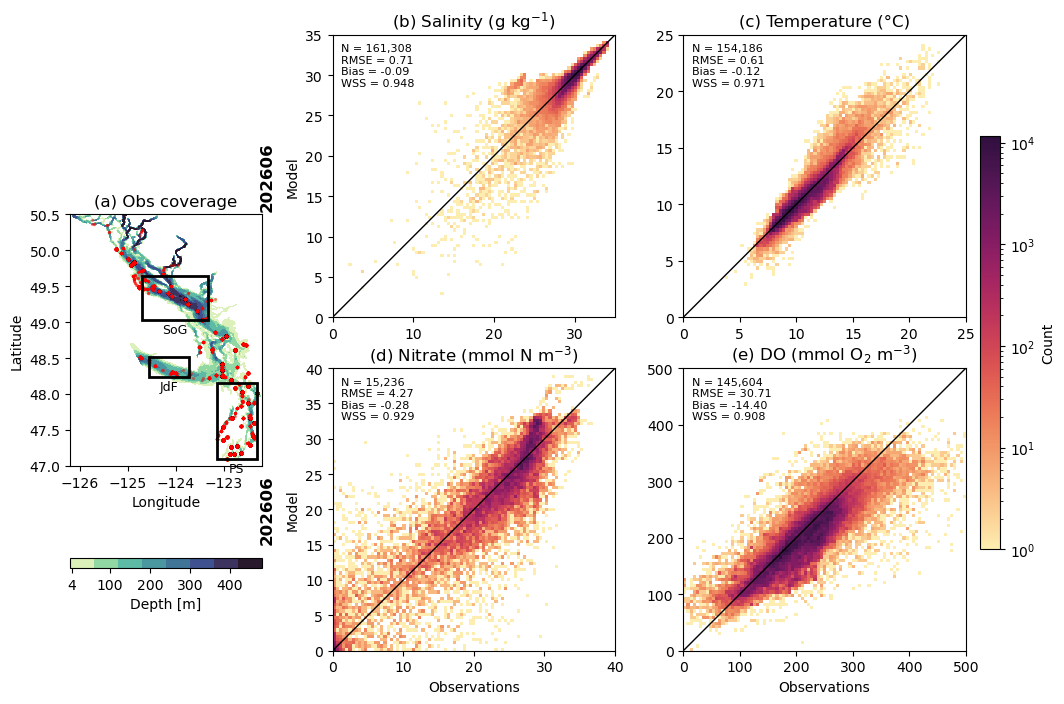

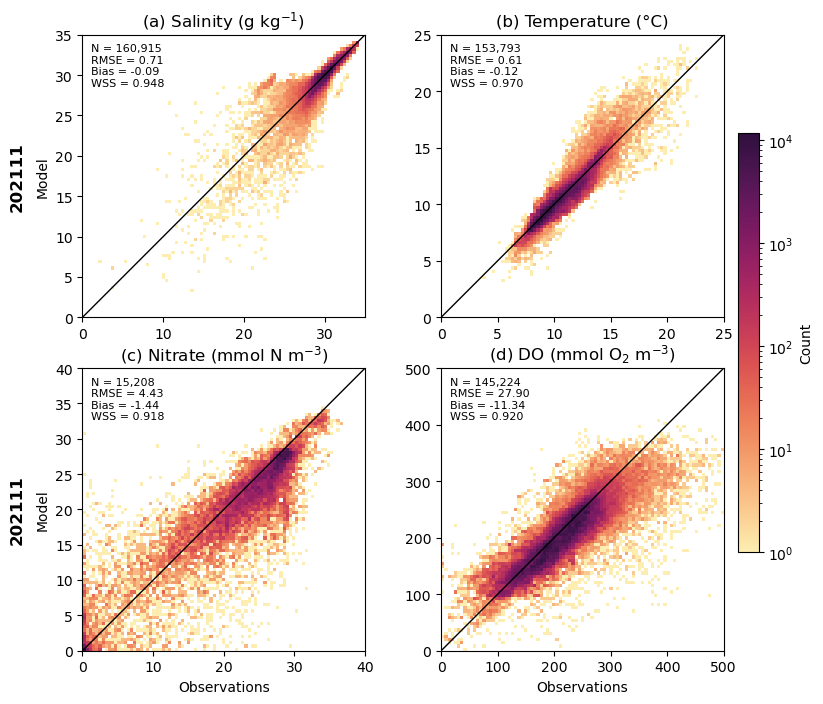

In [18]:
fig = plt.figure(figsize=(12,8))

gs = fig.add_gridspec(2, 3,width_ratios=[0.6,1,1],hspace=0.18,wspace=0.18)

axS   = fig.add_subplot(gs[0,1])
axT   = fig.add_subplot(gs[0,2])
axMap = fig.add_subplot(gs[:,0])

axDO  = fig.add_subplot(gs[1,2])
axNO3 = fig.add_subplot(gs[1,1])

h = scatter_panel(axS,df_S,"Salinity","mod_vosaline","(b) Salinity (g kg$^{-1}$)",(0,35),np.linspace(0,35,90))

scatter_panel(axT,df_T,"Temperature","mod_votemper","(c) Temperature (°C)",(0,25),np.linspace(0,25,90))

scatter_panel(axDO,df_DO,"Oxygen_Dissolved","mod_dissolved_oxygen","(e) DO (mmol O$_2$ m$^{-3}$)",(0,500),np.linspace(0,500,90))

scatter_panel(axNO3,df_NO3,"NO3","mod_nitrate","(d) Nitrate (mmol N m$^{-3}$)",(0,40),np.linspace(0,40,90))

axS.text(-0.23, 0.5, "202606", transform=axS.transAxes,rotation=90, va="center", ha="center", fontsize=12, fontweight="bold")
axDO.text(-0.23, 0.5, "202606", transform=axNO3.transAxes,rotation=90, va="center", ha="center", fontsize=12, fontweight="bold")
axS.set_ylabel("Model")
axNO3.set_ylabel("Model")
axDO.set_xlabel("Observations")
axNO3.set_xlabel("Observations")

# Observation coverage
obs_plot = obs.sample(min(25000, len(obs)),random_state=42)
mycmap = cm.deep
mycmap.set_bad('grey')
c = axMap.contourf(navlon,navlat,bathy.variables['Bathymetry'][:], cmap=mycmap, vmin=0, vmax=450)
axMap.scatter(obs_plot["Lon"],obs_plot["Lat"],s=2,color="red",alpha=0.35,rasterized=True)
for region in region_boxes:
    draw_region_box(axMap, region)
cbard = fig.colorbar(c, ax=axMap, orientation='horizontal', label='Depth [m]', ticks=[4,100,200,300,400])
# Limits
axMap.set_xlim(-126.2, -122.2)
axMap.set_ylim(47.0, 50.5)

axMap.set_aspect(1.5)

axMap.set_title("(a) Obs coverage")

axMap.set_xlabel("Longitude")
axMap.set_ylabel("Latitude")

cbar = fig.colorbar(
    h[3],
    ax=[axS, axT, axDO, axNO3],
    fraction=0.03,
    pad=0.02,
)

cbar.set_label("Count")

fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/ModelObsPointbyPoint_SSea_Revision.png',dpi=300)
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/ModelObsPointbyPoint_SSea_Revision.pdf',dpi=300)


# Figure S1: Obs vs Model for 202111
fig = plt.figure(figsize=(9,8))

gs = fig.add_gridspec(2, 2,width_ratios=[1,1],hspace=0.18,wspace=0.18)

axS   = fig.add_subplot(gs[0,0])
axT   = fig.add_subplot(gs[0,1])
axDO  = fig.add_subplot(gs[1,1])
axNO3 = fig.add_subplot(gs[1,0])

h = scatter_panel(axS,df_S21,"Salinity","mod_vosaline","(a) Salinity (g kg$^{-1}$)",(0,35),np.linspace(0,35,90))

scatter_panel(axT,df_T21,"Temperature","mod_votemper","(b) Temperature (°C)",(0,25),np.linspace(0,25,90))

scatter_panel(axDO,df_DO21,"Oxygen_Dissolved","mod_dissolved_oxygen","(d) DO (mmol O$_2$ m$^{-3}$)",(0,500),np.linspace(0,500,90))

scatter_panel(axNO3,df_NO321,"NO3","mod_nitrate","(c) Nitrate (mmol N m$^{-3}$)",(0,40),np.linspace(0,40,90))

axS.text(-0.23, 0.5, "202111", transform=axS.transAxes,rotation=90, va="center", ha="center", fontsize=12, fontweight="bold")
axDO.text(-0.23, 0.5, "202111", transform=axNO3.transAxes,rotation=90, va="center", ha="center", fontsize=12, fontweight="bold")
axS.set_ylabel("Model")
axNO3.set_ylabel("Model")
axDO.set_xlabel("Observations")
axNO3.set_xlabel("Observations")

cbar = fig.colorbar(h[3],ax=[axS, axT, axDO, axNO3],fraction=0.03,pad=0.02)

cbar.set_label("Count")

fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/ModelObsPointbyPoint_SSea_202111_FigS1.png',dpi=300)

fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/ModelObsPointbyPoint_SSea_202111_FigS1.pdf',dpi=300)



#### Depth-dependent evaluation

In [19]:
do_stats = depth_stats[depth_stats["Variable"] == "DO"].copy()
nit_stats = depth_stats[depth_stats["Variable"] == "NO3"].copy()

#### Figure S2

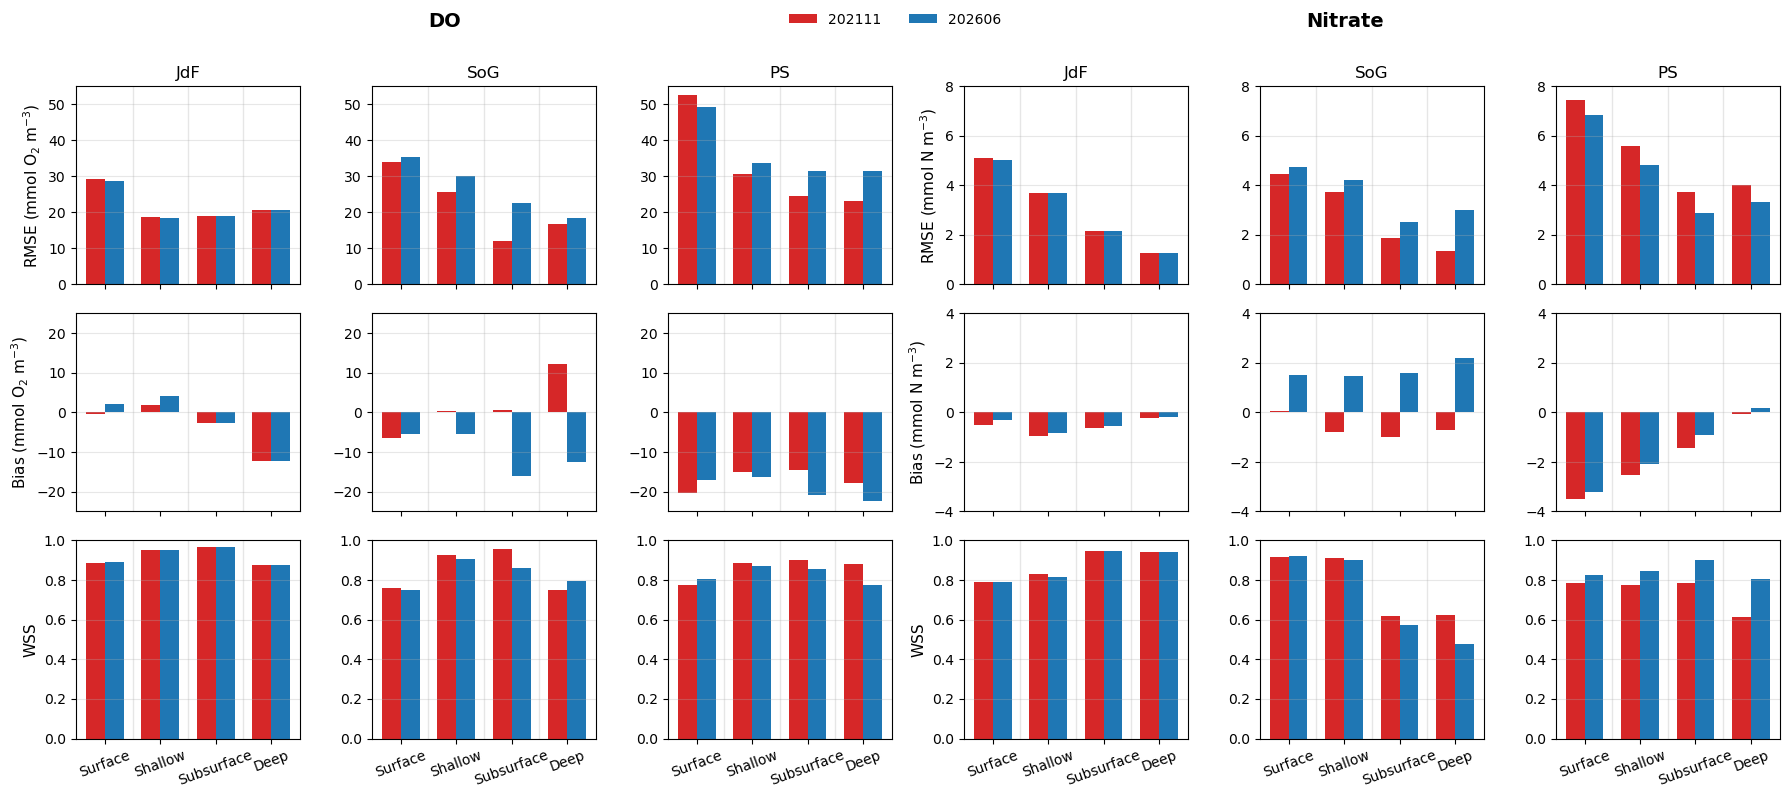

In [20]:
metrics = ["RMSE", "Bias", "WSS"]
metric_labels = {
    "DO": {"RMSE": r"RMSE (mmol O$_2$ m$^{-3}$)","Bias": r"Bias (mmol O$_2$ m$^{-3}$)","WSS": "WSS"},
    "NO$_3$": {"RMSE": r"RMSE (mmol N m$^{-3}$)","Bias": r"Bias (mmol N m$^{-3}$)","WSS": "WSS"}
    }
limits = {
    "DO": {"RMSE": (0, 55),"Bias": (-25, 25),"WSS": (0, 1)},
    "NO$_3$": {"RMSE": (0, 8),"Bias": (-4, 4),"WSS": (0, 1)}
    }
regions = ["JdF", "SoG", "PS"]

depth_order = ["Surface", "Shallow", "Subsurface", "Deep",]

variables = {"DO": do_stats,"NO$_3$": nit_stats,}

versions = ["202111", "202606"]

colors = {"202111": "tab:red", "202606": "tab:blue"}

bar_width = 0.34
x = np.arange(len(depth_order))

# Figure
fig, axs = plt.subplots(len(metrics),len(regions) * len(variables),figsize=(18,8),sharex=True)

#
for ivar, (varname, stats_df) in enumerate(variables.items()):
    for c, region in enumerate(regions):
        region_df = stats_df[stats_df["Region"] == region]
        for r, metric in enumerate(metrics):
            ax = axs[r, c + ivar*3]
            for n, version in enumerate(versions):
                tmp = (region_df[region_df["Version"] == version].set_index("Depth").loc[depth_order])
                offset = (-0.5 + n) * bar_width
                ax.bar(x + offset,tmp[metric].values,width=bar_width,color=colors[version],
                    label=version if (r==0 and c==0 and ivar==0) else None)

            ax.set_xticks(x)
            ax.set_xticklabels(depth_order, rotation=20)
            ax.grid(axis="y",alpha=0.3)

            for xx in np.arange(0.5, len(depth_order)-0.5):
                ax.axvline(xx,color="0.9",lw=1,zorder=0)

            if r == 0:
                ax.set_title(region, fontsize=12)

            if c == 0:
                ax.set_ylabel(metric_labels[varname][metric],fontsize=11)

            ax.set_ylim(*limits[varname][metric])

fig.text(0.25,0.97,"DO",ha="center",fontsize=14,fontweight="bold")

fig.text(0.75,0.97,"Nitrate",ha="center",fontsize=14,fontweight="bold")

handles, labels = axs[0,0].get_legend_handles_labels()

fig.legend(handles,labels,loc="upper center",ncol=2,frameon=False)

plt.tight_layout(rect=[0,0,1,0.94])

plt.savefig("/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/FigS2_DepthDependentSkill_DO_NO3.png",dpi=300)
plt.savefig("/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/FigS2_DepthDependentSkill_DO_NO3.pdf",dpi=300)
plt.show()

#### Evaluation under low-oxygen conditions

In [21]:
LOW_DO = 150

lowDO = {}

for version in ["202111","202606"]:

    lowDO[version] = {}

    for region in regions:

        df = regional_data[version][region]

        lowDO[version][region] = df[(df["Oxygen_Dissolved"] <= LOW_DO) & df["Oxygen_Dissolved"].notna() & df["mod_dissolved_oxygen"].notna()].copy()

In [22]:
def lowDO_scatter(ax, df, title=None):

    bins = np.linspace(0, LOW_DO, 80)

    norm = LogNorm(vmin=1, vmax=6500)

    h = ax.hist2d(df["Oxygen_Dissolved"],df["mod_dissolved_oxygen"],bins=[bins, bins],norm=norm,cmap=cm.matter)

#    ax.plot([0, LOW_DO], [0, LOW_DO], "k--", lw=1)

    thresholds = {"JdF": 65, "SoG": 115, "PS": 100,}
    thr = thresholds[region]
    ax.plot([thr, thr],[0, thr], "--", color="k", lw=1.2)
    ax.plot([0, thr],[thr, thr], "--", color="k", lw=1.2)
    low = np.sum((df["Oxygen_Dissolved"] < thr) & (df["mod_dissolved_oxygen"] < thr))

    stats = compute_stats(df["Oxygen_Dissolved"].values,df["mod_dissolved_oxygen"].values)

    txt_stats = (f"N = {stats['N']}\n"f"RMSE = {stats['RMSE']:.1f}\n"f"Bias = {stats['Bias']:.1f}\n"f"WSS = {stats['WSS']:.2f}")
    txt_lowDO = (f"Low DO sample: {low}")

    ax.text(0.01, 0.99, txt_stats,transform=ax.transAxes,va="top",fontsize=8,bbox=dict(facecolor='none',alpha=0.7,edgecolor='none'))
    #for region in thresholds:
    y_txt = 0.48 if region == "JdF" else 0.81 if region == "SoG" else 0.71
    ax.text(0.01, 0.15, txt_lowDO,transform=ax.transAxes,va="top",fontsize=8,bbox=dict(facecolor='none',alpha=0.7,edgecolor='none'))

    ax.set_xlim(0, LOW_DO)
    ax.set_ylim(0, LOW_DO)
    ax.set_aspect("equal")

    if title:
        ax.set_title(title)

    return h

#### Figure 3

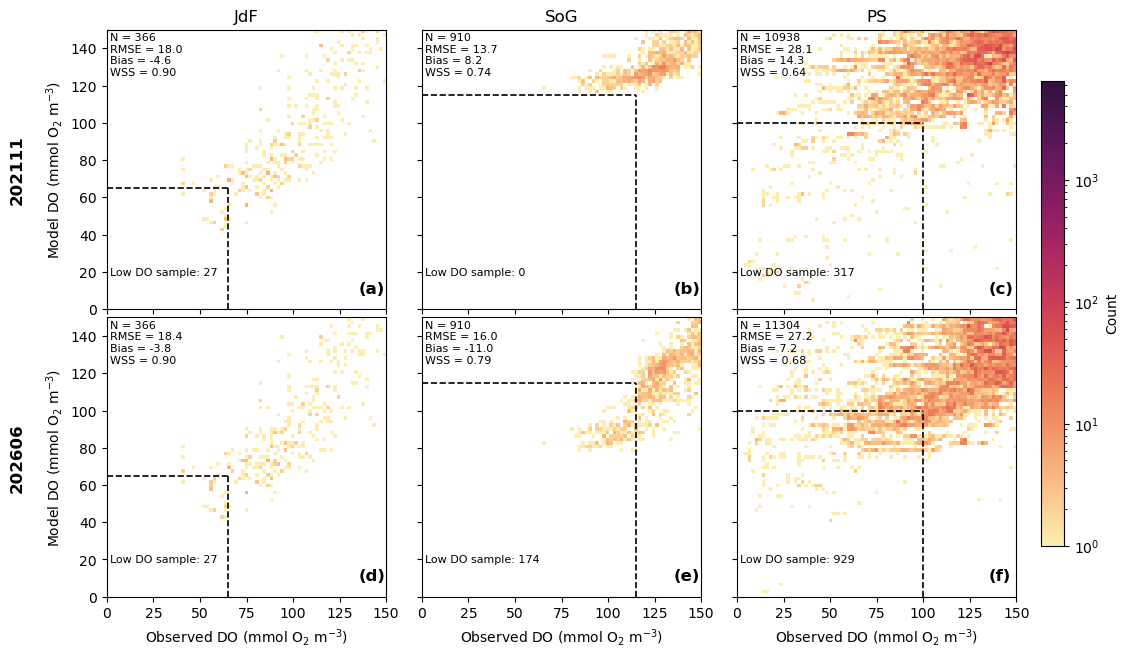

In [23]:
fig, axs = plt.subplots(2, 3,figsize=(12, 7),sharex=True,sharey=True)

regions = ["JdF", "SoG", "PS"]
versions = ["202111", "202606"]

for r, version in enumerate(versions):
    for c, region in enumerate(regions):

        # Save hist2d object for colorbar
        h = lowDO_scatter(axs[r, c],lowDO[version][region],
            title=region if r == 0 else None)

for ax in axs[1, :]:
    ax.set_xlabel("Observed DO (mmol O$_2$ m$^{-3}$)")
for ax in axs[:, 0]:
    ax.set_ylabel("Model DO (mmol O$_2$ m$^{-3}$)")

# Remove repeated tick labels
for ax in axs[0, :]:
    ax.tick_params(labelbottom=False)

for ax in axs[:, 1:].flat:
    ax.tick_params(labelleft=False)

axs[0,0].text(-0.32, 0.5, "202111", transform=axs[0,0].transAxes, rotation=90, va="center", ha="center", fontsize=12, fontweight="bold")

axs[1,0].text(-0.32, 0.5, "202606", transform=axs[1,0].transAxes,rotation=90, va="center", ha="center", fontsize=12, fontweight="bold")

cbar = fig.colorbar(h[3], ax=axs,location="right",fraction=0.025, pad=0.01)

cbar.set_label("Count")

letters = ['(a)','(b)','(c)','(d)','(e)','(f)']

k = 0
for r in range(2):
    for c in range(3):
        axs[r,c].text(0.9,0.1,letters[k],transform=axs[r,c].transAxes,fontweight='bold',va='top',fontsize=12)
        k += 1

fig.subplots_adjust(left=0.08, right=0.86, bottom=0.09, top=0.90, wspace=0.03, hspace=0.03,)
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/ModelObsPointbyPoint_LowDO.png',dpi=300)
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/ModelObsPointbyPoint_LowDO.pdf',dpi=300)